In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

In [2]:
news2_train = pd.read_csv(
    "news2_train.tsv",
    sep='\t'
)

news2_test = pd.read_csv(
    "news2_test.tsv",
    sep='\t'
)

In [3]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [4]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [5]:
news2_test[news2_test['NEWS2'].isna()]

,injection,NEWS2,SOFA_admission_from_ambulance,SOFA_admission_from_ambulance_increase,SOFA_admision_from_ed,SOFA_admission__from_ed_increase
421,SA_BOX_15-769_S4-D1_1_6695,NaN,0,0,2,2


In [6]:
design_matrix_test = design_matrix_test.set_index("injection").join(
    news2_test.set_index("injection"),
).reset_index()

In [7]:
design_matrix = design_matrix.set_index("injection").join(
    news2_train.set_index("injection"),
).reset_index()

In [8]:
design_matrix.shape

(680, 76)

In [9]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [10]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['survival_7_day'] = np.where(design_matrix['survival_days'] <= 7, 1, 0)
design_matrix_test['survival_7_day'] = np.where(design_matrix_test['survival_days'] <= 7, 1, 0)

design_matrix['survival_1_day'] = np.where(design_matrix['survival_days'] <= 1, 1, 0)
design_matrix_test['survival_1_day'] = np.where(design_matrix_test['survival_days'] <= 1, 1, 0)


design_matrix['survival_2_day'] = np.where(design_matrix['survival_days'] <= 2, 1, 0)
design_matrix_test['survival_2_day'] = np.where(design_matrix_test['survival_days'] <= 2, 1, 0)


design_matrix['survival_3_day'] = np.where(design_matrix['survival_days'] <= 3, 1, 0)
design_matrix_test['survival_3_day'] = np.where(design_matrix_test['survival_days'] <= 3, 1, 0)


In [11]:
design_matrix_test['qsofa_resp'] = np.where(
    design_matrix_test['resp_frequency_ambulance'] >= 22, 1, 0
)

design_matrix_test['qsofa_sysbp'] = np.where(
    design_matrix_test['syst_bp_ambulance'] <= 100, 1, 0
)

design_matrix_test['qsofa_mental'] = np.where(
    design_matrix_test['mental_status_ambulance'] > 1, 1, 0
)

In [12]:
for col in design_matrix.columns:

    if "sofa" in col:

        print(col)

sofa_score_increase_day1
sofa_score_increase_day2
sofa_score_increase_day3
sofa_resp_day1
sofa_resp_day2
sofa_resp_day3
sofa_resp_baseline
sofa_renal_day1
sofa_renal_day2
sofa_renal_day3
sofa_renal_baseline
sofa_cardiovasc_day1
sofa_cardiovasc_day2
sofa_cardiovasc_day3
sofa_cardiovasc_baseline
sofa_coag_day1
sofa_coag_day2
sofa_coag_day3
sofa_coag_baseline
sofa_cns_day1
sofa_cns_day2
sofa_cns_day3
sofa_cns_baseline
sofa_liver_day1
sofa_liver_day2
sofa_liver_day3
sofa_liver_baseline


In [13]:
sofa_col = 'sofa_score_increase_day1'

In [14]:
qsofa_columns = [
    'qsofa_resp',
    'qsofa_sysbp',
    'qsofa_mental',
]

In [15]:
design_matrix_test['qsofa'] = design_matrix_test[qsofa_columns].sum(axis=1)

<Axes: >

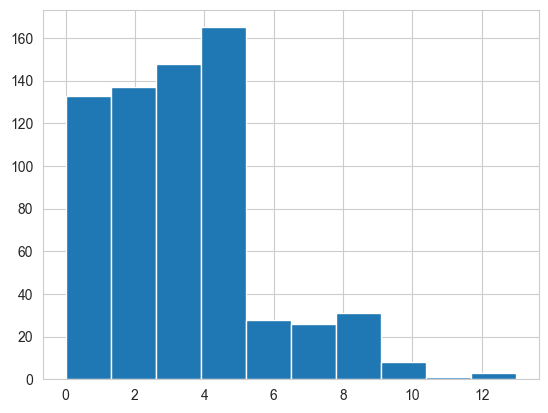

In [16]:
design_matrix_test[sofa_col].hist()

In [17]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])


In [18]:
df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    bootstrap_replace=False,
    bootstrap_fraction=0.9,
    bootstrap_iterations=1000
)
df_estimator.fit(training_data, features=clinical_columns)

In [19]:
testing_data['Mortality Rate'] = df_estimator.predict(
    testing_data[clinical_columns], 
    features=clinical_columns, 
    target_column="survival_30_day",
    bootstrap=True
)

testing_data['Sepsis Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column="sepsis_or_septic_shock",
    bootstrap=True
)

testing_data['Infection Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column="verified_infection",
    bootstrap=True
)

testing_data['ICU Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column="critical_care",
    bootstrap=True
)

In [21]:
from sklearn.metrics import RocCurveDisplay, roc_curve

In [23]:
testing_data['NEWS2'] = testing_data['NEWS2'].fillna(0.0)

In [24]:
from sklearn.metrics import roc_auc_score


roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data['Mortality Rate'],
)

0.7058864653243848

In [25]:
roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data['NEWS2'],
)

0.6274868168744007

In [27]:
((0.71 - 0.63) / 0.63) * 100

12.698412698412692

In [34]:
dt_30_day_fpr, dt_30_day_tpr, _ = roc_curve(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data['Mortality Rate'],
)

qsofa_30_day_fpr, qsofa_30_day_tpr, _ = roc_curve(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["qsofa"],
)

news2_30_day_fpr, news2_30_day_tpr, _ = roc_curve(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["NEWS2"],
)

sofa_30_day_fpr, sofa_30_day_tpr, _ = roc_curve(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["SOFA_admission_from_ambulance_increase"],
)

dt_roc_auc = roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["Mortality Rate"],
)

news2_roc_auc = roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["NEWS2"],
)

qsofa_roc_auc = roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["qsofa"],
)

sofa_roc_auc = roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["SOFA_admission_from_ambulance_increase"],
)

dt_roc_auc_partial = roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["Mortality Rate"],
    max_fpr=0.20
)

news2_roc_auc_partial = roc_auc_score(
    y_true=testing_data['survival_30_day'],
    y_score=testing_data["NEWS2"],
    max_fpr=0.20
)


In [35]:
(dt_roc_auc_partial - news2_roc_auc_partial) / dt_roc_auc_partial

0.0927941823971259

In [36]:
colors = sns.color_palette("mako", 4)

In [37]:
colors[0]

(0.2213631, 0.16471913, 0.33041431)

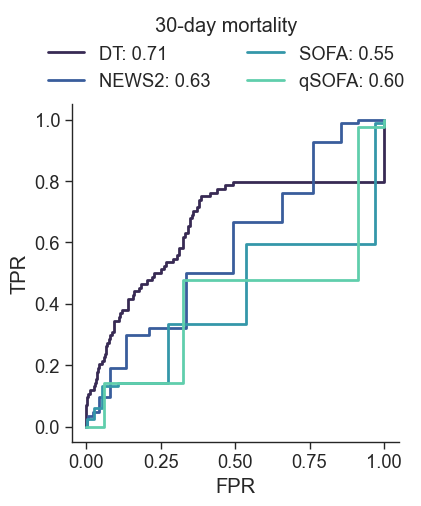

In [58]:
import matplotlib.pyplot as plt

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)


fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(4, 4),
    constrained_layout=True,
    sharex=True
)

# axs = axs.flatten()

## 30 day mortality

axs.step(
    x=dt_30_day_fpr,
    y=dt_30_day_tpr,
    where='post',
    label=f"DT: {dt_roc_auc:.2f}",
    c=colors[0],
    lw=2

)
axs.step(
    x=news2_30_day_fpr,
    y=news2_30_day_tpr,
    where='post',
    label=f"NEWS2: {news2_roc_auc:.2f}",
    c=colors[1],
    lw=2
)

axs.step(
    x=sofa_30_day_fpr,
    y=sofa_30_day_tpr,
    where='post',
    label=f"SOFA: {sofa_roc_auc:.2f}",
    c=colors[2],
    lw=2
)

axs.step(
    x=qsofa_30_day_fpr,
    y=qsofa_30_day_tpr,
    where='post',
    label=f"qSOFA: {qsofa_roc_auc:.2f}",
    c=colors[3],
    lw=2
)


axs.set_xlabel("FPR")
axs.set_ylabel("TPR")

axs.legend()

sns.move_legend(axs, "upper left", bbox_to_anchor=(1, 1))

handles, labels = axs.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(.55, 1.25), frameon=False, ncol=2, markerscale=1.5, title="30-day mortality")
axs.legend().remove()

fig.savefig(
    "30_day_mortality_comparison.pdf",
    bbox_inches='tight',
    transparent=True,
    dpi=300,
)